## Библиотеки и константы


In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import scipy.stats as stats
import pylab
import struct
import json
import os
from IPython.display import clear_output
from math import factorial
from collections import defaultdict
from itertools import product, combinations, permutations
import inspect
import time

%matplotlib inline

In [2]:
n_exp = 10000

n_exp = 500
n_discs = 5000
n_substats = 4

TOTAL_COUNT = 1_000_000
BATCH_SIZE = 10_000

ARTIFACT_FORMAT = "<10i"
ARTIFACT_SIZE = struct.calcsize(ARTIFACT_FORMAT)

### Базовые значения

In [3]:
stats_map = {
    "HP%": 0,
    "HP": 1, 
    "ATK%": 2,
    "ATK": 3,
    "DEF%": 4,
    "DEF": 5,
    "PEN": 6,
    "AP": 7, # Anomaly Proficiency
    "CRIT_RATE": 8,
    "CRIT_DMG": 9,
    "PEN%": 10,
    "AM": 11,
    "Impact": 12,
    "ER": 13,
    "Physical Bonus": 14,
    "Fire Bonus": 15,
    "Ice Bonus": 16,
    "Electric Bonus": 17,
    "Ether Bonus": 18,
    "Wind Bonus": 19,
    "None": 100,
}

stat_names = [""] * (max(stats_map.values()) + 1)
for name, stat_id in stats_map.items():
    if stat_id >= 0:
        stat_names[stat_id] = name

main_stat_values_map = {
    stats_map["HP%"]: 3000,
    stats_map["HP"]: 2200, 
    stats_map["ATK%"]: 3000,
    stats_map["ATK"]: 316,
    stats_map["DEF%"]: 4800,
    stats_map["DEF"]: 184, 
    stats_map["AP"]: 92,
    stats_map["CRIT_RATE"]: 2400,
    stats_map["CRIT_DMG"]: 4800,
    stats_map["PEN%"]: 2400,
    stats_map["Physical Bonus"]: 3000, # same for all elements
    stats_map["AM"]: 3000,
    stats_map["ER"]: 6000,
    stats_map["Impact"]: 1800
}

base_sub_stats_choices = np.array([
    stats_map["HP%"],
    stats_map["HP"], 
    stats_map["ATK%"],
    stats_map["ATK"],
    stats_map["DEF%"],
    stats_map["DEF"],
    stats_map["PEN"],
    stats_map["AP"],
    stats_map["CRIT_RATE"],
    stats_map["CRIT_DMG"]
], dtype=np.int32)

# 100%, 90%, 80%, 70%
sub_stat_values = np.array([
    300, # HP%
    112, # HP
    300, # ATK%
    19, # ATK
    480, # DEF%
    15, # DEF
    9, # PEN
    9, # AP
    240, # CRIT_RATE
    480, # CRIT_DMG
              
], dtype=np.int32)

sub_stats_weights = np.array([
    113, # HP%
    103, # HP
    90, # ATK%
    98, # ATK
    131, # DEF%
    112, # DEF
    107, # PEN
    97, # AP
    116, # CRIT_RATE
    104, # CRIT_DMG
              
], dtype=np.int32)

enka_stat_map = {
    11102: stats_map["HP%"],
    11103: stats_map["HP"], 
    12102: stats_map["ATK%"],
    12103: stats_map["ATK"],
    13102: stats_map["DEF%"],
    13103: stats_map["DEF"], 
    31203: stats_map["AP"],
    20103: stats_map["CRIT_RATE"],
    21103: stats_map["CRIT_DMG"],
    23103: stats_map["PEN%"],
    23203: stats_map["PEN"],
    31503: stats_map["Physical Bonus"],
    31603: stats_map["Fire Bonus"],
    31703: stats_map["Ice Bonus"],
    31803: stats_map["Electric Bonus"],
    31903: stats_map["Ether Bonus"],
    32303: stats_map["Wind Bonus"],
    31402: stats_map["AM"],
    30502: stats_map["ER"],
    12202: stats_map["Impact"]
}

BASE_STAT_IDS = {
    11101: "HP",
    12101: "ATK",
    13101: "DEF"
}

file_names = {'HP%', 'HP', 'ATK%', 'ATK', 'DEF%', 'DEF', 'AP', "CRIT_RATE", "CRIT_DMG"}

profit_names = {name: 0.0 for name in stat_names[:10]}

In [4]:
slot_1_pop = [stats_map["HP"]]
slot_1_prob = np.array([1], dtype=float)

slot_2_pop = [stats_map["ATK"]]
slot_2_prob = np.array([1], dtype=float)

slot_3_pop = [stats_map["DEF"]]
slot_3_prob = np.array([1], dtype=float)

slot_4_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["CRIT_RATE"],
    stats_map["CRIT_DMG"],
    stats_map["AP"]
]
slot_4_prob = np.array([1, 1, 1, 1, 1, 1], dtype=float)
slot_4_prob /= slot_4_prob.sum()

slot_5_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["PEN%"],
    stats_map["Physical Bonus"],
    stats_map["Fire Bonus"],
    stats_map["Ice Bonus"],
    stats_map["Electric Bonus"],
    stats_map["Ether Bonus"],
    stats_map["Wind Bonus"]
]
slot_5_prob = np.array([2, 2, 2, 1, 1, 1, 1, 1, 1], dtype=float)
slot_5_prob /= slot_5_prob.sum()


slot_6_pop = [
    stats_map["HP%"],
    stats_map["ATK%"],
    stats_map["DEF%"],
    stats_map["AM"],
    stats_map["ER"],
    stats_map["Impact"]
]
slot_6_prob = np.array([2, 2, 2, 2, 2, 1], dtype=float)
slot_6_prob /= slot_6_prob.sum()


slots_prob = {
    1: (slot_1_pop, slot_1_prob),
    2: (slot_2_pop, slot_2_prob),
    3: (slot_3_pop, slot_3_prob),
    4: (slot_4_pop, slot_4_prob),
    5: (slot_5_pop, slot_5_prob),
    6: (slot_6_pop, slot_6_prob),
}



In [5]:
disc_cache = {}


def load_discs(main_stat):
    if main_stat >= 10:
        main_stat = 100
    if main_stat not in disc_cache:
        data = np.load(f"discs/{stat_names[main_stat]}.npz")

        disc_cache[main_stat] = (
            data["substats"],
            data["probabilities"]
        )

    return disc_cache[main_stat]

### Функции

In [6]:
def get_2_best_stat(main_stat, profit_order):
    best_stats = [
        stat for stat in profit_order
        if stat != main_stat
    ][:2]

    return best_stats[0], best_stats[1]

def get_disc_score(disc, profit, profit_order):
    main_stat = disc["main_stat"]["id"]
    slot = disc["slot"]
    best_stat_1, best_stat_2 = get_2_best_stat(main_stat, profit_order)
    main_stat_pop, main_stat_prob = slots_prob[slot]
    idx = main_stat_pop.index(main_stat)

    all_substats, probabilities = load_discs(main_stat)

    current_utility = np.dot(
        disc["substats"],
        profit
    )

    all_utilities = all_substats @ profit
    better = all_utilities > current_utility
    p_better = probabilities[better].sum()
    
    disc["craft_main_probability"] =  round(p_better, 6)
    disc["score"] = round((1 - p_better * main_stat_prob[idx]) * 100, 4)
    
    selected_1 = (
        all_substats[:, best_stat_1] > 0
    )

    selected_2 = (
        selected_1
        & (all_substats[:, best_stat_2] > 0)
    )
    
    disc["craft_one_probability"] = round(
        probabilities[better & selected_1].sum()
        / probabilities[selected_1].sum()
    , 6)

    disc["craft_two_probability"] = round(
        probabilities[better & selected_2].sum()
        / probabilities[selected_2].sum()
    , 6)


def evaluate_characters(uid, update_characters=None):
    if update_characters is None:
        update_characters = []
    file_path = f"characters/{uid}.json"

    with open(file_path, "r", encoding="utf-8") as file:
        characters = json.load(file)

    for character in characters.values():
        if (
            character["score"] > 1
            and character["name_ru"] not in update_characters
        ):
            continue
        profit = np.array(character["profit"])
        profit_order = np.argsort(profit)[::-1]

        total_score = 0

        for disc in character["discs"]:
            get_disc_score(disc, profit, profit_order)
            total_score += disc["score"]

        character["score"] = round(total_score, 2)

    with open(file_path, "w", encoding="utf-8") as file:
        json.dump(
            characters,
            file,
            ensure_ascii=False,
            indent=4
        )

    return characters
        

In [7]:
def plot_character_discs(character):
    discs = sorted(
        character["discs"],
        key=lambda disc: disc["slot"]
    )
    name = character["name_ru"]
    slots = [disc["slot"] for disc in discs]
    scores = [disc["score"] for disc in discs]

    plt.figure(figsize=(9, 5))

    bars = plt.bar(slots, scores)

    for bar, score in zip(bars, scores):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            score + 1,
            f"{score:.1f}",
            ha="center"
        )

    plt.ylim(0, 105)
    plt.xlabel("Слот диска")
    plt.ylabel("Оценка")
    plt.title(
        f"{name} — диски "
        f"(общая оценка {character['score']:.1f})"
    )

    plt.tight_layout()
    plt.show()
    
def plot_characters(characters):
    sorted_characters = sorted(
        characters.items(),
        key=lambda x: x[1]["score"],
        reverse=True
    )

    names = [char["name_ru"] for _, char in sorted_characters]
    scores = [
        character["score"]
        for _, character in sorted_characters
    ]

    plt.figure(figsize=(12, len(names) / 3.5))

    bars = plt.barh(names, scores)

    for bar, score in zip(bars, scores):
        plt.text(
            score + 2,
            bar.get_y() + bar.get_height() / 2,
            f"{score:.1f}",
            va="center"
        )

    plt.xlim(0, 630)
    plt.xlabel("Суммарная оценка дисков")
    plt.title("Оценка персонажей")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()
    
def print_all_discs(characters):
    all_discs = []

    for character_name, character in characters.items():
        for disc in character["discs"]:
            all_discs.append(
                (
                    disc["score"],
                    character["name_ru"],
                    disc
                )
            )

    all_discs.sort(key=lambda x: x[0])

    for score, character_name, disc in all_discs:
        print(
            f"{score:7.3f} | "
            f"{character_name:15} | "
            f"слот {disc['slot']} | "
            f"{disc['main_stat']['name']}"
        )

        print(
            f"    Main: "
            f"{disc['craft_main_probability'] * 100:.3f}% | "
            f"выбор 1: {disc['craft_one_probability'] * 100:.3f}% | "
            f"выбор 2: {disc['craft_two_probability'] * 100:.3f}%\n"
        )

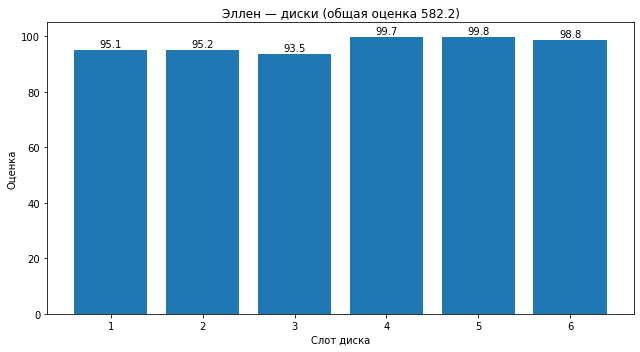

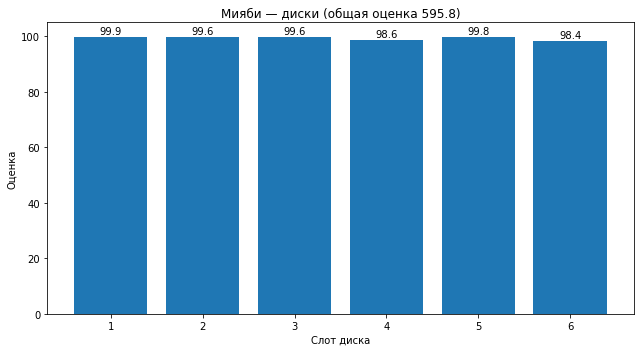

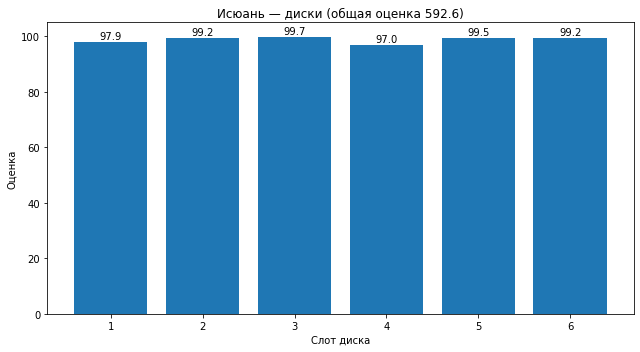

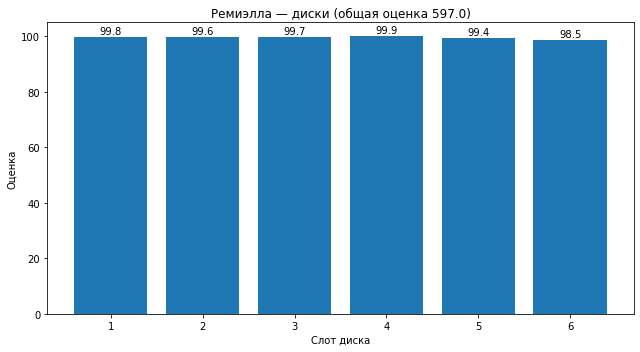

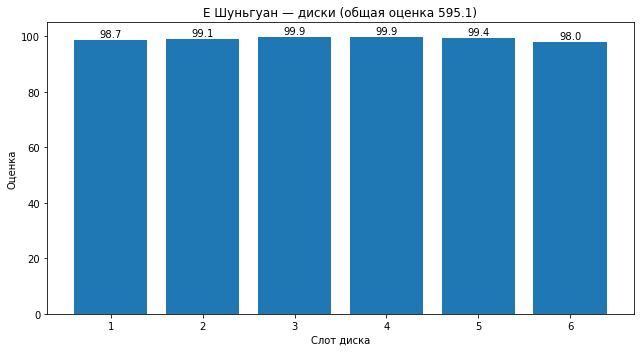

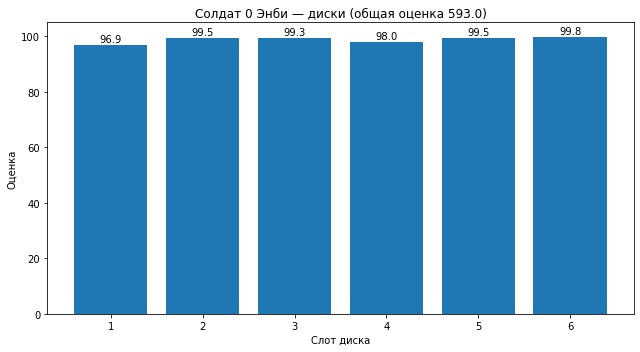

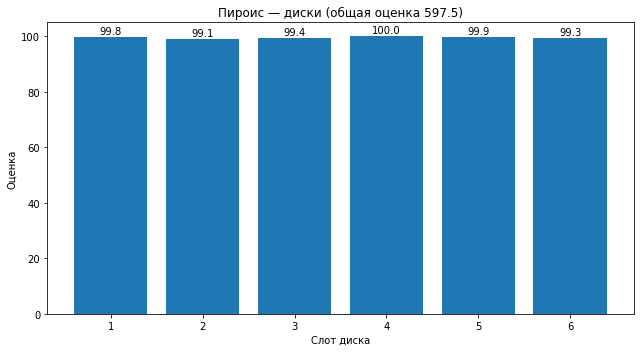

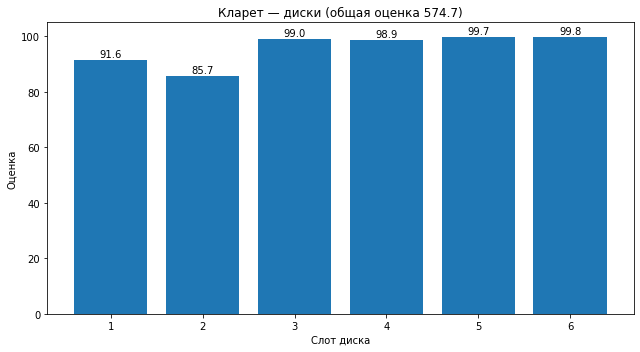

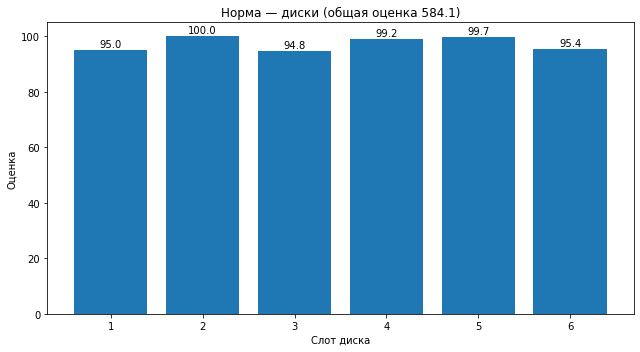

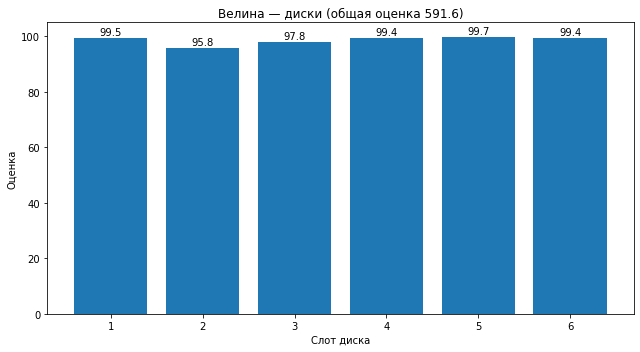

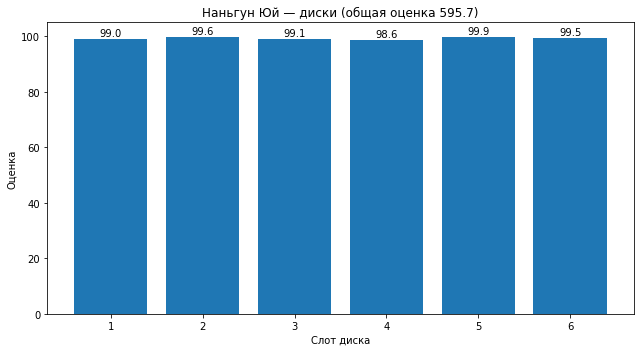

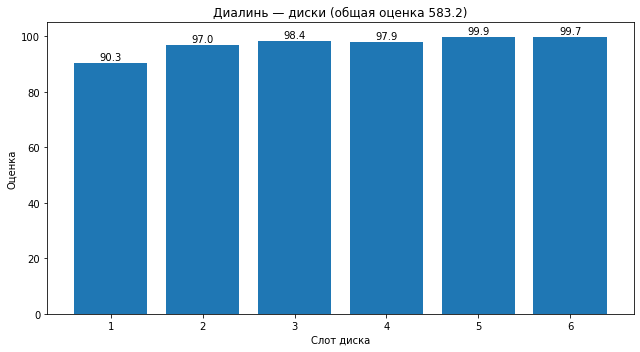

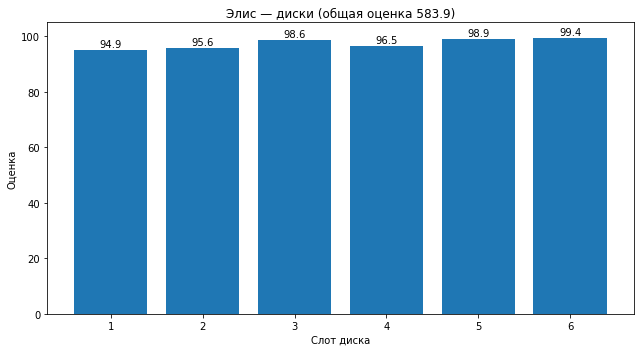

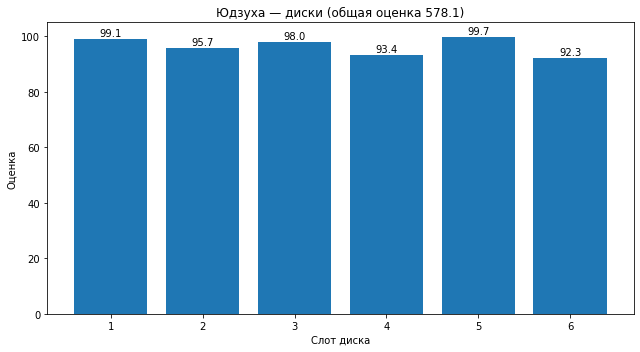

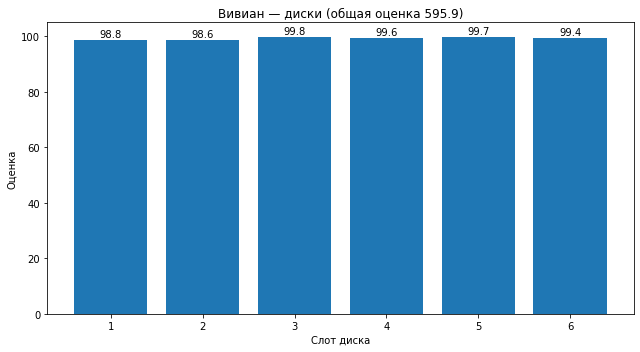

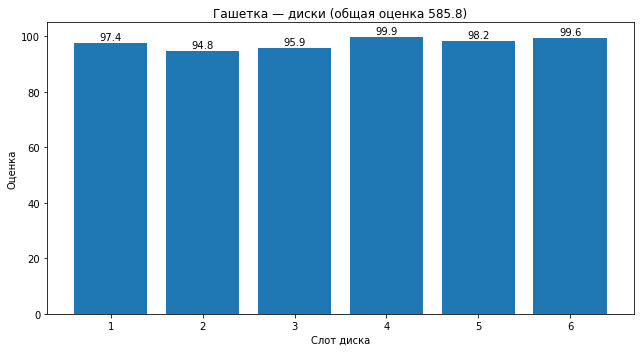

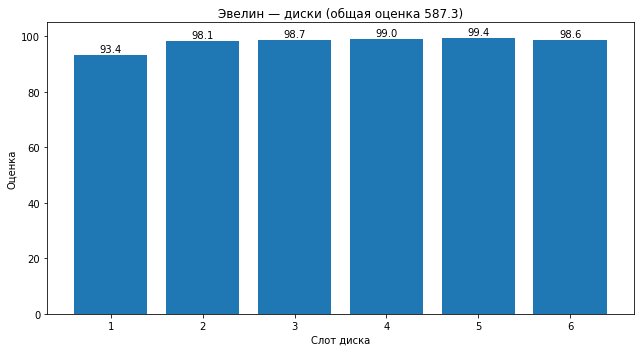

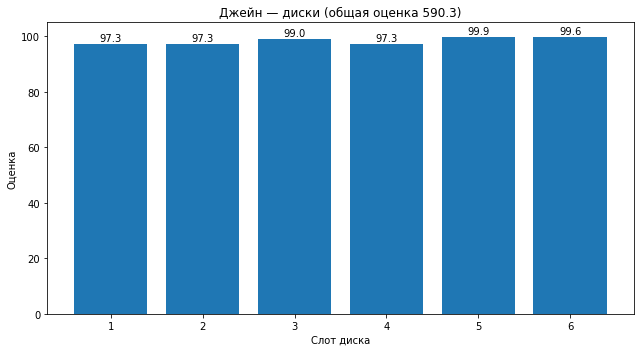

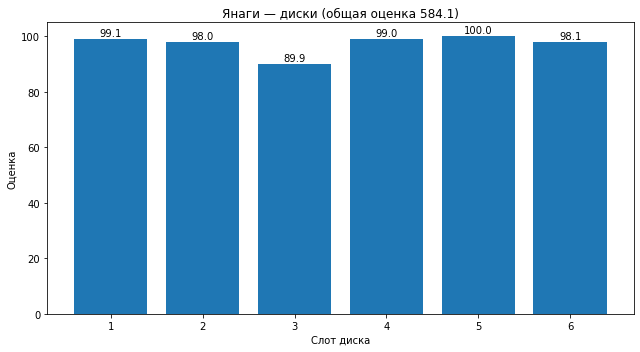

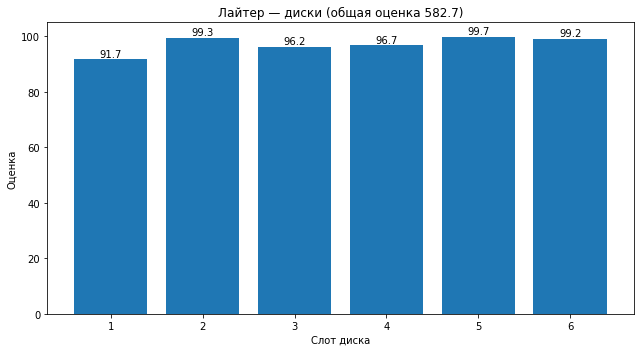

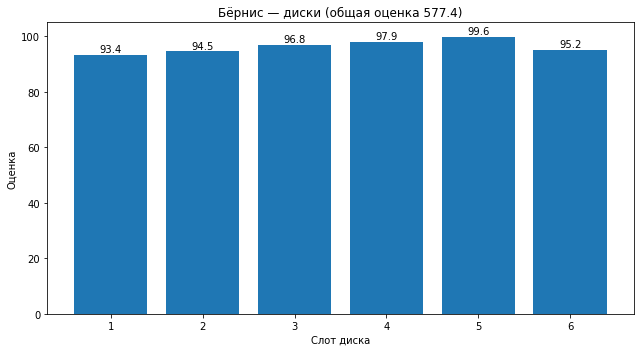

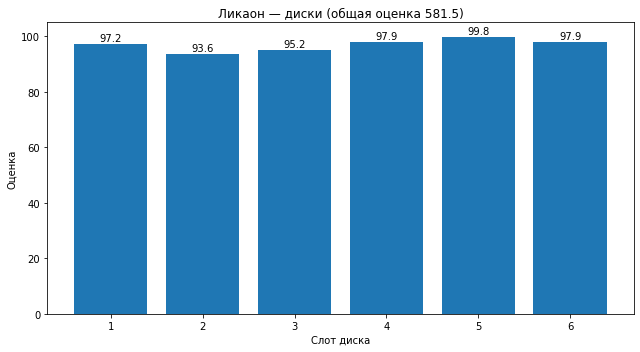

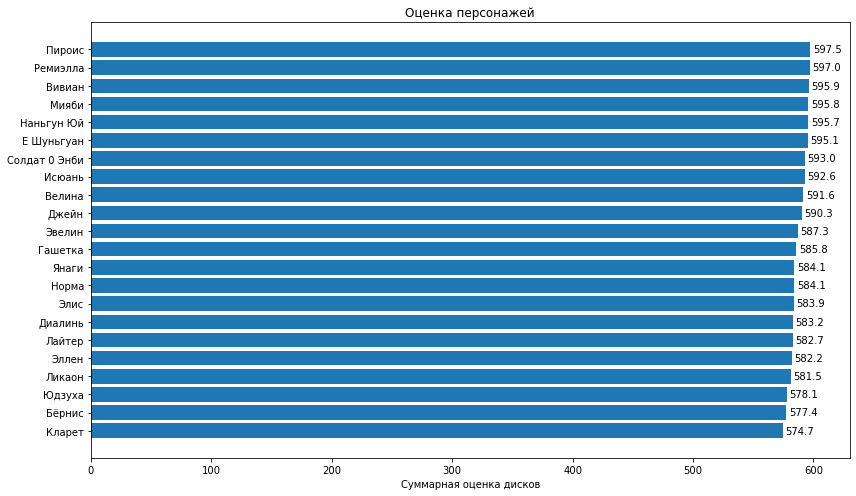


Диски от худшего к лучшему:
 85.739 | Кларет          | слот 2 | ATK
    Main: 14.261% | выбор 1: 26.144% | выбор 2: 46.366%

 89.884 | Янаги           | слот 3 | DEF
    Main: 10.116% | выбор 1: 24.148% | выбор 2: 51.792%

 90.303 | Диалинь         | слот 1 | HP
    Main: 9.697% | выбор 1: 22.418% | выбор 2: 41.883%

 91.579 | Кларет          | слот 1 | HP
    Main: 8.421% | выбор 1: 15.910% | выбор 2: 30.899%

 91.667 | Лайтер          | слот 1 | HP
    Main: 8.333% | выбор 1: 17.027% | выбор 2: 37.848%

 92.303 | Юдзуха          | слот 6 | AM
    Main: 42.331% | выбор 1: 71.768% | выбор 2: 97.575%

 93.351 | Юдзуха          | слот 4 | ATK%
    Main: 39.896% | выбор 1: 83.373% | выбор 2: 93.405%

 93.384 | Эвелин          | слот 1 | HP
    Main: 6.616% | выбор 1: 13.488% | выбор 2: 29.911%

 93.424 | Бёрнис          | слот 1 | HP
    Main: 6.575% | выбор 1: 15.952% | выбор 2: 36.891%

 93.483 | Эллен           | слот 3 | DEF
    Main: 6.517% | выбор 1: 11.814% | выбор 2: 22.652%

 9

In [11]:
uid = 1500018666
start_time = time.time()
characters = evaluate_characters(uid)

for name, character in characters.items():
    plot_character_discs(character)

plot_characters(characters)

print()
print("Диски от худшего к лучшему:")
end_time = time.time()
print_all_discs(characters)
print(f"--- {end_time - start_time} seconds of all disks ---")